# Multiple Linear Regression

## Tujuan

Notebook ini bertujuan untuk membangun model Multiple Linear Regression untuk memprediksi jumlah produk terjual (`sold`) berdasarkan beberapa fitur numerik pada dataset hasil scraping Shopee.

Tahapan yang dilakukan meliputi:

- Pemilihan fitur
- Pembagian data latih dan data uji
- Pelatihan model
- Evaluasi model
- Interpretasi hasil

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("../data/processed/ecommerce.csv")

In [2]:
features = [
    "price_avg",
    "discount_percent",
    "rating",
    "review_count",
    "seller_followers",
    "seller_rating",
    "seller_age"
]

X = df[features]

y = df["sold"]

In [3]:
X = X.fillna(0)

## Train-Test Split

Dataset dibagi menjadi:

- 80% data latih
- 20% data uji

Pembagian dilakukan menggunakan `train_test_split` dengan `random_state=42` agar hasil dapat direproduksi.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Training Model

In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0. ,16.77,-0.01,..., 0. ,-0. , 8.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['price_avg','discount_percent','rating',...,'seller_followers', 'seller_rating','seller_age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1501
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


Prediction

In [6]:
y_pred = model.predict(X_test)

## Evaluasi Model

Evaluasi dilakukan menggunakan empat metrik:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

In [7]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1503.56
MSE  : 4217404.81
RMSE : 2053.63
R²   : 0.4495


Koefisien Regresi

In [8]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,discount_percent,16.769257
6,seller_age,8.099239
3,review_count,0.239928
4,seller_followers,0.001064
0,price_avg,-0.000119
5,seller_rating,-0.000837
2,rating,-0.010257


Intercept

In [9]:
print(model.intercept_)

1500.5352290092037


Actual vs Prediction

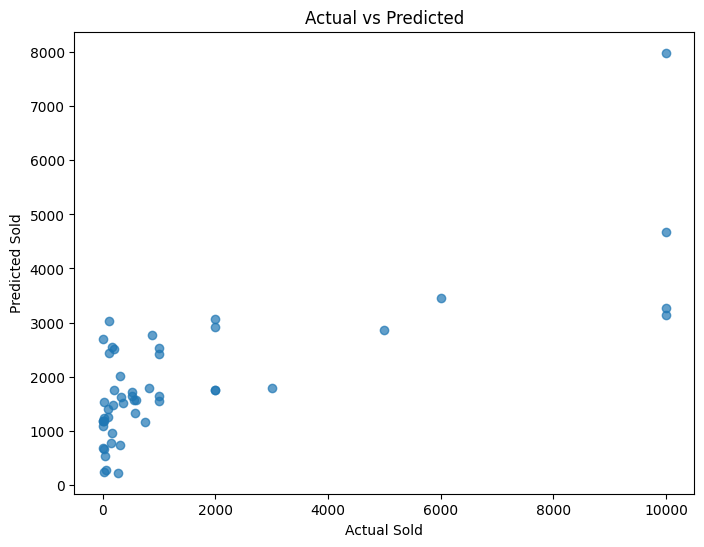

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel("Actual Sold")

plt.ylabel("Predicted Sold")

plt.title("Actual vs Predicted")

plt.show()

Residual

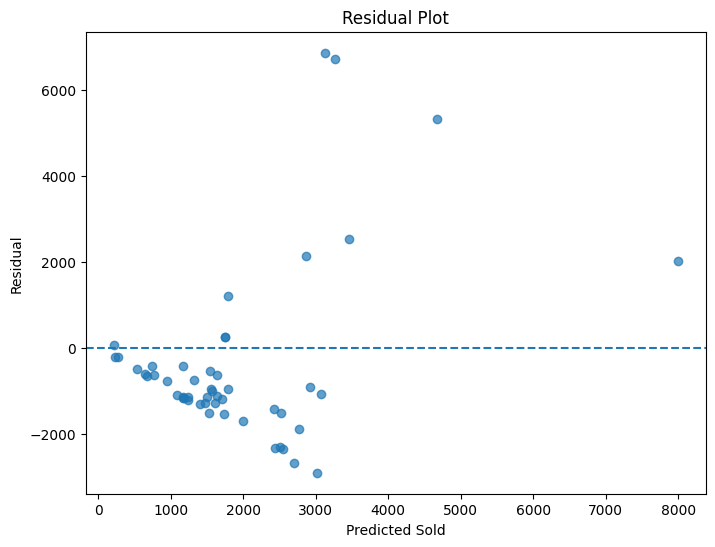

In [11]:
residual = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residual,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sold")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()